In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'B:\python project\Global_Superstore2.csv',encoding = 'latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [5]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [6]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [7]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [8]:
df = df.drop_duplicates()
print('duplicate hat gaye')

duplicate hat gaye


In [9]:
category_sales = df.groupby('Category')['Sales'].sum()

In [10]:
category_sales = category_sales.sort_values(ascending=False)

In [11]:
print(category_sales)

Category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: Sales, dtype: float64


In [12]:
pd.set_option('display.float_format', lambda x: '%.2f' %x)

In [13]:
print(category_sales)

Category
Technology        4744557.50
Furniture         4110874.19
Office Supplies   3787070.23
Name: Sales, dtype: float64


In [14]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

In [15]:
print(subcat_profit)

Sub-Category
Copiers       258567.55
Phones        216717.01
Bookcases     161924.42
Appliances    141680.59
Chairs        140396.27
Accessories   129626.31
Storage       108461.49
Binders        72449.85
Paper          59207.68
Machines       58867.87
Art            57953.91
Furnishings    46967.43
Envelopes      29601.12
Supplies       22583.26
Labels         15010.51
Fasteners      11525.42
Tables        -64083.39
Name: Profit, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

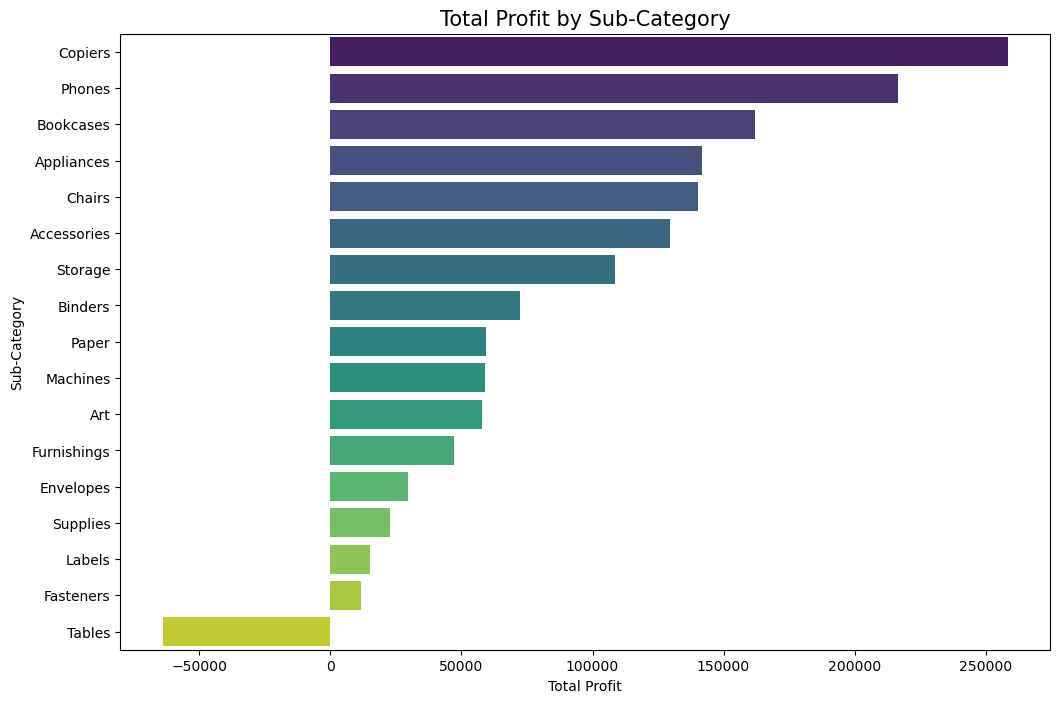

In [17]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(x=subcat_profit.values, y=subcat_profit.index, hue=subcat_profit.index ,palette='viridis')

plt.title('Total Profit by Sub-Category', fontsize=15)
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')

plt.show()

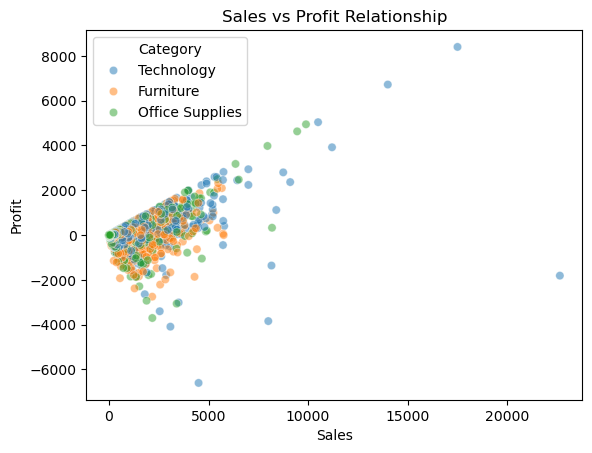

In [18]:
sns.scatterplot(data=df,x='Sales' ,y='Profit', hue='Category', alpha=0.5)
plt.title('Sales vs Profit Relationship')
plt.show()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  object        
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     51290 non-null  float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [21]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_sales  = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Motnth_year'] = monthly_sales['Month_Year'].astype(str)
print(monthly_sales.head())

  Month_Year     Sales Motnth_year
0    2011-01  98898.49     2011-01
1    2011-02  91152.16     2011-02
2    2011-03 145729.37     2011-03
3    2011-04 116915.76     2011-04
4    2011-05 146747.84     2011-05


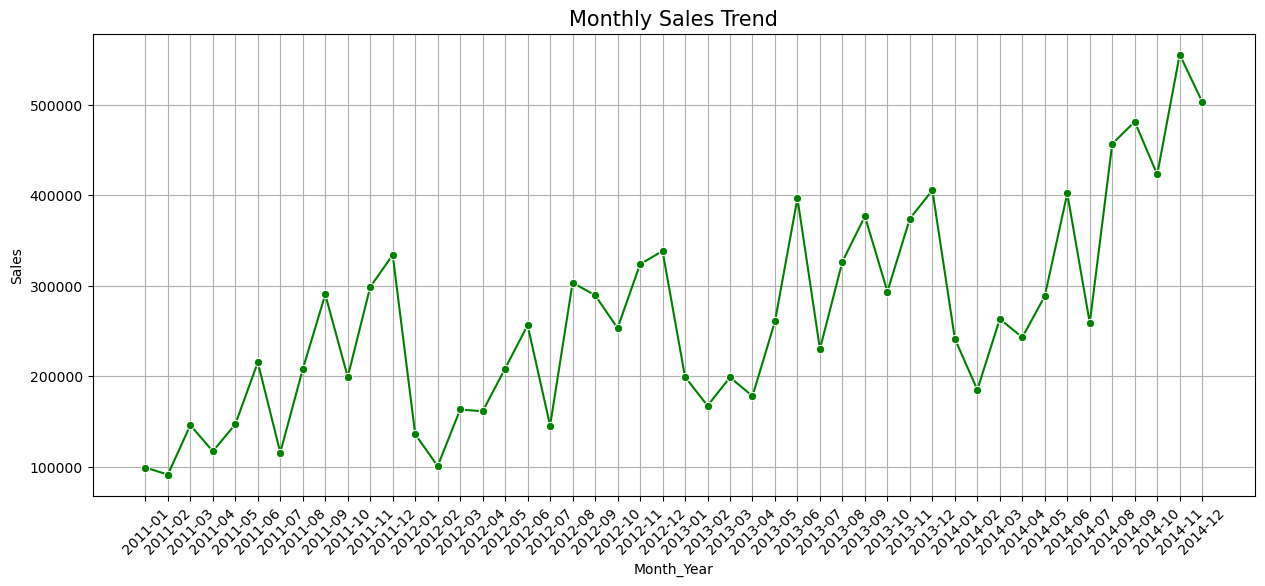

In [25]:
plt.figure(figsize=(15,6))
sns.lineplot(x=monthly_sales['Month_Year'].astype(str), y=monthly_sales['Sales'] , marker='o' , color= 'green')
plt.title('Monthly Sales Trend', fontsize = 15)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [27]:
top_customers = df.groupby('Customer Name').agg({'Sales':'sum', 'Profit':'sum'})
top_5= top_customers.nlargest(5, 'Sales')
print(top_5)

                      Sales  Profit
Customer Name                      
Tom Ashbrook       40488.07 6311.98
Tamara Chand       37457.33 8672.90
Greg Tran          35550.95 5214.13
Christopher Conant 35187.08 5603.33
Sean Miller        35170.93 -409.71


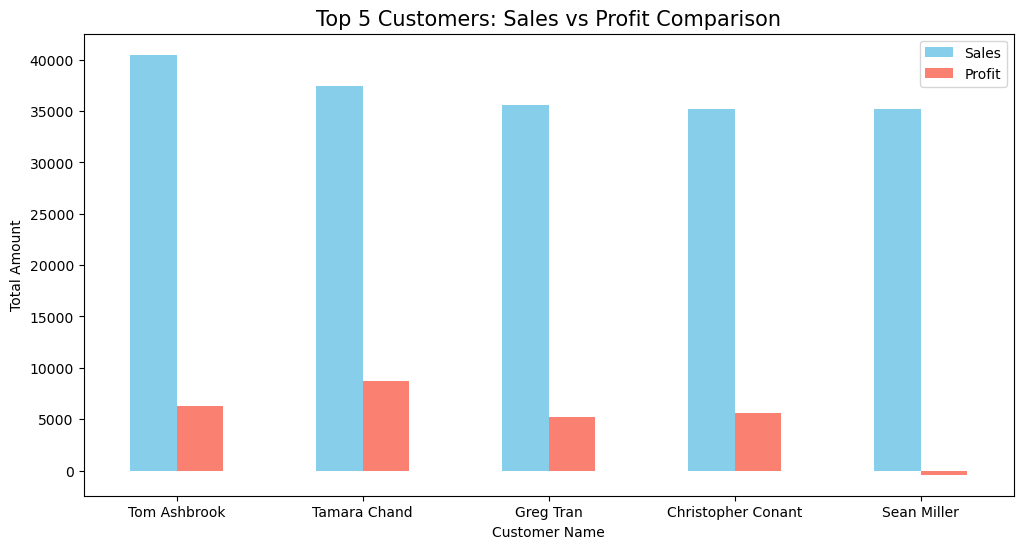

In [28]:
top_5.plot(kind='bar' , figsize=(12,6), color = ['skyblue', 'salmon'])
plt.title('Top 5 Customers: Sales vs Profit Comparison',fontsize=15)
plt.xlabel('Customer Name')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.show()

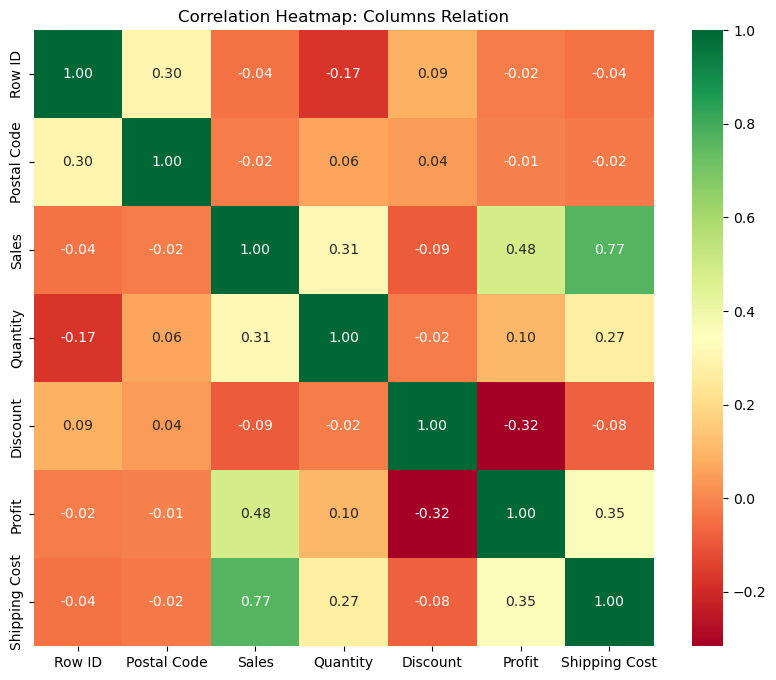

In [31]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap: Columns Relation')
plt.show()

In [33]:
def region_report(region_name):
    region_data = df[df['Region'] == region_name]
    total_s = region_data['Sales'].sum()
    total_p = region_data['Profit'].sum()
    print(f"--- Report for {region_name} ---")
    print(f"Total Sales: {total_s:.2f}")
    print(f"Total Profit: {total_p:.2f}")
    print(f"Profit Margin: {(total_p/total_s)*100:.2f}%")
region_report('Central')

--- Report for Central ---
Total Sales: 2822302.52
Total Profit: 311403.98
Profit Margin: 11.03%


In [34]:
avg_order_value = df['Sales'].mean()
predicted_sales = avg_order_value * 100
print(f"Current Avg Order Value: {avg_order_value:.2f}")
print(f"Predicted Sales for next 100 orders: {predicted_sales:.2f}")

Current Avg Order Value: 246.49
Predicted Sales for next 100 orders: 24649.06
